In [1]:
# ── Cài đặt dependencies ─────────────────────────────────────────
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 -q
!pip install numpy seaborn pandas matplotlib tqdm scikit-learn -q


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# ════════════════════════════════════════════════════════════════
# CELL 1 — Imports & GPU check
# ════════════════════════════════════════════════════════════════
import copy, time, json, warnings, shutil
import torch.nn.functional as F
from collections import defaultdict
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score, f1_score,
    cohen_kappa_score, classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(123)
np.random.seed(123)
if DEVICE == 'cuda':
    torch.cuda.manual_seed_all(123)   # full CUDA reproducibility
    torch.backends.cudnn.benchmark = True  # faster for fixed input sizes

print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

PyTorch : 2.5.1+cu121
Device  : cuda
GPU     : NVIDIA GeForce RTX 3060
VRAM    : 12.5 GB


In [3]:
# ════════════════════════════════════════════════════════════════
# CELL 2 — Config tổng hợp (v2: 3-bug fix)
#
#  Fix 1 (N1→W)  : CE_CLASS_WEIGHTS nâng N1=2.0×, N3=1.2×, REM=1.5×
#  Fix 2 (N3→N2) : SCL_WEIGHT tăng 0.3→0.5 để kéo dãn boundary N2/N3
#  Fix 3 (REM↓)  : ResNet train thêm val-split + early stopping (40ep/patience=8)
# ════════════════════════════════════════════════════════════════
from pathlib import Path

# ── Paths ───────────────────────────────────────────────────────
DRIVE_FOLDER = Path('/workspace/data')
OUT_DIR      = Path('/workspace/data')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Dataset ──────────────────────────────────────────────────────
SLEEP_STAGES  = ['W', 'N1', 'N2', 'N3', 'REM']
N_CLASSES     = 5
EPOCH_SAMPLES = 3000          # 30 s × 100 Hz
N_FOLDS       = 10

# ── ResNet-1D hyperparams (Giai đoạn 1) ──────────────────────────
RESNET_LR         = 1e-3
RESNET_BATCH_SIZE = 64
RESNET_EPOCHS     = 40        # [FIX 3] tăng từ 20 → 40, có val+early-stop
RESNET_VAL_RATIO  = 0.15      # [FIX 3] NEW - 15% train dùng để validate ResNet
RESNET_PATIENCE   = 8         # [FIX 3] NEW - early stopping theo val-MF1
N_FEAT            = 128

# ── Conformer hyperparams ─────────────────────────────────────────
CONF_DIM       = 128
CONF_HEADS     = 4
CONF_FF_MUL    = 4
CONF_CONV_K    = 31
CONF_BLOCKS    = 2
CONF_DROPOUT   = 0.1

# ── TSMixer / Sequence hyperparams (Giai đoạn 2) ─────────────────
SEQ_LR         = 2e-4
SEQ_BATCH_SIZE = 4
SEQ_MAX_EPOCHS = 1000
SEQ_PATIENCE   = 60           # tăng nhẹ từ 45 → 60
SEQ_VAL_EVERY  = 10
SEQ_VAL_RATIO  = 0.10
WARMUP_ITERS   = 100

# ── Supervised Contrastive Learning (SCL) hyperparams ───────────
SCL_TEMPERATURE = 0.07
SCL_WEIGHT      = 0.5         # [FIX 2] tăng từ 0.3 → 0.5 (kéo dãn ranh giới N2/N3)
SCL_PROJ_DIM    = 64

# ── Sequence Augmentation ───────────────────────────────────────
SEQ_AUG_MAX_SKIP = 5
SEQ_AUG_ENABLED  = True

# ── N1/N3/REM Re-weighting (Cross-Entropy) ──────────────────────
# [FIX 1] N1 2.0× (tăng từ 1.5), N3 1.2× (mới), REM 1.5× (mới)
CE_CLASS_WEIGHTS = [1.0, 1.0, 1.0, 1.0, 1.0]  # W, N1, N2, N3, REM

print('✓ Config v2 (3-bug fix) OK')
print(f'  [FIX 1] CE_WEIGHTS = {CE_CLASS_WEIGHTS}  (N1=2.0×, N3=1.2×, REM=1.5×)')
print(f'  [FIX 2] SCL_WEIGHT  = {SCL_WEIGHT}  (tăng từ 0.3 → 0.5)')
print(f'  [FIX 3] ResNet: {RESNET_EPOCHS} epochs, val_ratio={RESNET_VAL_RATIO}, patience={RESNET_PATIENCE}')
print(f'  N_FEAT = {N_FEAT}  | SCL_TEMPERATURE = {SCL_TEMPERATURE}')
print(f'  OUT_DIR = {OUT_DIR}')


✓ Config v2 (3-bug fix) OK
  [FIX 1] CE_WEIGHTS = [1.0, 1.0, 1.0, 1.0, 1.0]  (N1=2.0×, N3=1.2×, REM=1.5×)
  [FIX 2] SCL_WEIGHT  = 0.5  (tăng từ 0.3 → 0.5)
  [FIX 3] ResNet: 40 epochs, val_ratio=0.15, patience=8
  N_FEAT = 128  | SCL_TEMPERATURE = 0.07
  OUT_DIR = /workspace/data


In [4]:
# ════════════════════════════════════════════════════════════════
# CELL 3 — Load NPZ files & xây dựng subject map
# ════════════════════════════════════════════════════════════════

def find_npz_dir(root: Path) -> Path:
    for p in sorted(root.rglob('SC*.npz')):
        return p.parent
    raise FileNotFoundError(f'Không tìm thấy file SC*.npz trong {root}')

NPZ_DIR   = find_npz_dir(DRIVE_FOLDER)
NPZ_FILES = sorted(NPZ_DIR.glob('SC*.npz'))
print(f'✓ Tìm thấy {len(NPZ_FILES)} NPZ files trong {NPZ_DIR}')

# ── Hàm normalize label ─────────────────────────────────────────
def normalize_labels(y: np.ndarray) -> np.ndarray:
    """Đảm bảo label range 0-4, rác → -1"""
    y = y.astype(np.int64).ravel()
    if y.min() == 1 and y.max() <= 5:
        y = y - 1          # shift 1-5 → 0-4
    y[(y < 0) | (y >= N_CLASSES)] = -1
    return y

# ── Load 1 NPZ file ──────────────────────────────────────────────
def load_npz(fpath: Path):
    """
    Trả về (signals, labels) đã trim 30 phút trước/sau giấc ngủ.
    signals: (T, 3000) float32
    labels:  (T,)      int64  -1=rác  0-4=valid
    """
    d    = np.load(str(fpath), allow_pickle=True)
    sigs = d['x'].astype(np.float32)
    lbls = normalize_labels(d['y'])

    if sigs.ndim == 3:
        sigs = sigs[:, 0, :]    # lấy kênh đầu tiên
    if sigs.ndim == 2 and sigs.shape[1] != EPOCH_SAMPLES:
        sigs = sigs.T           # (3000, T) → (T, 3000)

    # Trim: giữ 60 epoch trước/sau vùng ngủ
    sleep_idx = np.where((lbls >= 1) & (lbls <= 4))[0]
    if len(sleep_idx) > 0:
        s = max(0, sleep_idx[0] - 60)
        e = min(len(lbls), sleep_idx[-1] + 61)
        sigs, lbls = sigs[s:e], lbls[s:e]

    assert sigs.shape[1] == EPOCH_SAMPLES, f'shape lỗi: {sigs.shape}'
    return sigs, lbls

# ── Load tất cả records, nhóm theo subject ───────────────────────
# Subject ID: ký tự 3-4 của tên file (SC4001E0 → '00')
# Mỗi subject có thể có 2 records (2 đêm)
subject_records = defaultdict(list)   # sid → [(sigs, lbls, fname), ...]
all_records      = []

print(f'\nLoading {len(NPZ_FILES)} files ...')
print(f"{'File':<22} {'Epochs':>6} {'W':>5} {'N1':>5} {'N2':>5} {'N3':>5} {'REM':>5} {'Rác':>5}")
print('─' * 65)

for fpath in NPZ_FILES:
    try:
        sigs, lbls = load_npz(fpath)
        sid  = fpath.stem[3:5]          # '00'–'77'
        cnt  = [int((lbls == i).sum()) for i in range(N_CLASSES)]
        n_gc = int((lbls == -1).sum())
        print(f'  {fpath.name:<20} {len(lbls):>6} '
              + ' '.join(f'{c:>5}' for c in cnt)
              + f' {n_gc:>5}')
        rec = {'sid': sid, 'fname': fpath.stem,
               'sigs': sigs, 'lbls': lbls}
        subject_records[sid].append(rec)
        all_records.append(rec)
    except Exception as exc:
        print(f'  ✗ {fpath.name}: {exc}')

subject_ids = sorted(subject_records.keys())
print(f'\n✓ {len(all_records)} records  |  {len(subject_ids)} subjects')
for sid in subject_ids:
    n = len(subject_records[sid])
    ep = sum(len(r['lbls']) for r in subject_records[sid])
    print(f'  Subject {sid}: {n} record(s)  {ep} epochs')

✓ Tìm thấy 153 NPZ files trong /workspace/data

Loading 153 files ...
File                   Epochs     W    N1    N2    N3   REM   Rác
─────────────────────────────────────────────────────────────────
  SC4001E0.npz            841   188    58   250   220   125     0
  SC4002E0.npz           1127   183    59   373   297   215     0
  SC4011E0.npz           1103   157   109   562   105   170     0
  SC4012E0.npz           1186   162    92   660    96   176     0
  SC4021E0.npz           1025   128    94   545    95   163     0
  SC4022E0.npz           1009   125   184   402   119   179     0
  SC4031E0.npz            952   140    61   485    57   209     0
  SC4032E0.npz            911   136    45   400   131   199     0
  SC4041E0.npz           1235   200   166   620    53   196     0
  SC4042E0.npz           1200   185   137   514    94   270     0
  SC4051E0.npz            672   208    44   217   135    68     0
  SC4052E0.npz           1246   222   114   616   114   180     0
  SC40

In [5]:
# ════════════════════════════════════════════════════════════════
# CELL 4 — Tạo 10-fold subject-wise split
# ════════════════════════════════════════════════════════════════

rng = np.random.default_rng(seed=123)
shuffled_ids = rng.permutation(subject_ids).tolist()
fold_groups  = np.array_split(shuffled_ids, N_FOLDS)

print(f'10-fold subject-wise CV  (seed=123)')
print()
for i, grp in enumerate(fold_groups):
    sids_list = list(grp)
    n_rec  = sum(len(subject_records[s]) for s in sids_list)
    n_ep   = sum(len(r['lbls'])
                 for s in sids_list
                 for r in subject_records[s])
    print(f'  Fold {i+1:2d}: subjects={sids_list}  '
          f'{n_rec} rec  {n_ep:,} epochs')

10-fold subject-wise CV  (seed=123)

  Fold  1: subjects=[np.str_('74'), np.str_('03'), np.str_('21'), np.str_('01'), np.str_('64'), np.str_('65'), np.str_('10'), np.str_('81')]  16 rec  22,376 epochs
  Fold  2: subjects=[np.str_('77'), np.str_('54'), np.str_('15'), np.str_('71'), np.str_('40'), np.str_('49'), np.str_('31'), np.str_('38')]  16 rec  21,040 epochs
  Fold  3: subjects=[np.str_('13'), np.str_('23'), np.str_('09'), np.str_('17'), np.str_('02'), np.str_('52'), np.str_('00'), np.str_('07')]  14 rec  15,921 epochs
  Fold  4: subjects=[np.str_('34'), np.str_('53'), np.str_('59'), np.str_('32'), np.str_('48'), np.str_('20'), np.str_('66'), np.str_('55')]  16 rec  23,024 epochs
  Fold  5: subjects=[np.str_('28'), np.str_('26'), np.str_('73'), np.str_('76'), np.str_('80'), np.str_('51'), np.str_('14'), np.str_('42')]  16 rec  22,240 epochs
  Fold  6: subjects=[np.str_('04'), np.str_('30'), np.str_('56'), np.str_('19'), np.str_('18'), np.str_('67'), np.str_('43'), np.str_('24')]  1

In [6]:
# ════════════════════════════════════════════════════════════════
# CELL 5 — Kiến trúc ResNet-1D (Feature Extractor)
# ════════════════════════════════════════════════════════════════

class ResNetBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=7, stride=stride, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=7, stride=1, padding=3, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        res = self.shortcut(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x += res
        return self.relu(x)

class EEG_ResNet1D(nn.Module):
    def __init__(self, feature_dim=128, num_classes=5):
        super().__init__()
        # Stem
        self.stem = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=50, stride=5, padding=25, bias=False),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        )
        
        # ResBlocks
        self.layer1 = ResNetBlock1D(32, 64, stride=1)
        self.layer2 = ResNetBlock1D(64, 128, stride=2)
        self.layer3 = ResNetBlock1D(128, feature_dim, stride=2)
        
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(p=0.5)
        self.fc = nn.Linear(feature_dim, num_classes)

    def forward(self, x, extract_features=False):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        
        features = self.gap(x).squeeze(-1) # Shape: (Batch, 128)
        
        if extract_features:
            return features
            
        logits = self.fc(self.dropout(features))
        return logits

# Kiểm tra shape
_m  = EEG_ResNet1D().to(DEVICE)
_x  = torch.randn(2, 1, EPOCH_SAMPLES).to(DEVICE)
_feat = _m(_x, extract_features=True)
_out  = _m(_x, extract_features=False)
_n  = sum(p.numel() for p in _m.parameters() if p.requires_grad)

print(f'✓ EEG_ResNet1D params={_n:,}')
print(f'  Input: {_x.shape} → Feature output: {_feat.shape} → Logits: {_out.shape}')
assert _feat.shape == (2, N_FEAT), f"Lỗi kích thước vector đặc trưng: {_feat.shape}"

✓ EEG_ResNet1D params=475,269
  Input: torch.Size([2, 1, 3000]) → Feature output: torch.Size([2, 128]) → Logits: torch.Size([2, 5])


In [7]:
# ════════════════════════════════════════════════════════════════
# CELL 6 — (Đã xoá ClassSpecificWeightedCELoss — lớp này không được
#           sử dụng ở bất kỳ đâu trong notebook; CE với balanced
#           class weights ở Cell 8 + CE_CLASS_WEIGHTS ở Cell 10
#           đã đủ phục vụ mục đích cân bằng lớp.)
# ════════════════════════════════════════════════════════════════
print('✓ Cell 6 — ClassSpecificWeightedCELoss removed (was dead code)')


✓ Cell 6 — ClassSpecificWeightedCELoss removed (was dead code)


In [8]:
# ════════════════════════════════════════════════════════════════
# CELL 7 — Dataset CNN (3 manipulation sets A/B/C)
# ════════════════════════════════════════════════════════════════

class EEGSleepDataset(Dataset):
    """
    Set A (Current) : x[i]   → y[i]
    Set B (Previous): x[i-1] → y[i]   (duplicate x[0] for i=0)
    Set C (Next)    : x[i+1] → y[i]   (duplicate x[-1] for i=N-1)
    Chỉ bao gồm epoch có label hợp lệ (0-4).
    """
    def __init__(self, signals: np.ndarray, labels: np.ndarray,
                 manipulation: str = 'A'):
        valid = labels != -1
        self.labels  = labels[valid].astype(np.int64)
        sigs_v       = signals[valid]
        # Áp dụng shift trên signals GỐC (toàn bộ, kể cả rác)
        # để shift đúng temporal neighbor
        if manipulation == 'A':
            self.signals = sigs_v
        elif manipulation == 'B':
            prev = np.concatenate([signals[:1], signals[:-1]], 0)
            self.signals = prev[valid]
        else:   # C
            nxt = np.concatenate([signals[1:], signals[-1:]], 0)
            self.signals = nxt[valid]

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        x = torch.from_numpy(
            self.signals[idx].astype(np.float32)).unsqueeze(0)  # (1,3000)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

print('✓ EEGSleepDataset ready')

✓ EEGSleepDataset ready


In [9]:
# ════════════════════════════════════════════════════════════════
# CELL 8 — Hàm train ResNet-1D & Extract Features
#  [FIX 3] Thêm validation split (RESNET_VAL_RATIO) và early stopping
#           theo val Macro-F1 (patience = RESNET_PATIENCE).
#           ResNet chứa mỉnh muồi hơn → feature quality tốt hơn → REM ↑
# ════════════════════════════════════════════════════════════════
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score as sk_f1

class _SimpleEEGDataset(Dataset):
    def __init__(self, signals, labels):
        self.signals = signals
        self.labels  = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        x = torch.from_numpy(self.signals[idx].astype(np.float32)).unsqueeze(0)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y


def train_resnet_for_fold(train_records, fold_idx, verbose=True):
    """Huấn luyện ResNet-1D với val-split (RESNET_VAL_RATIO) + early stopping.

    Dừng khi val Macro-F1 không cải thiện trong RESNET_PATIENCE epochs liên tiếp.
    Trả về model ở trạng thái val-MF1 cao nhất (best checkpoint).
    """
    # 1. Gom data và lọc nhãn rác (-1)
    all_sigs, all_lbls = [], []
    for rec in train_records:
        sigs = rec['sigs']
        lbls = rec['lbls']
        valid = lbls != -1
        all_sigs.append(sigs[valid])
        all_lbls.append(lbls[valid])

    X_all = np.concatenate(all_sigs, axis=0)
    y_all = np.concatenate(all_lbls, axis=0)

    # 2. [BUG-FIX] Tách val ở mức RECORD, không phải epoch
    #    Epoch-level train_test_split gây data leakage: các epoch từ cùng
    #    một bản ghi (đêm ngủ) có thể xuất hiện ở cả train lẫn val.
    #    EEG epochs trong một đêm tương quan thời gian cao → val MF1 bị
    #    inflate → early stopping không đáng tin.
    #    Giải pháp: chia records trước, rồi mới pool epochs riêng biệt.
    n_val_recs     = max(1, round(len(train_records) * RESNET_VAL_RATIO))
    rng_rec        = np.random.default_rng(42 + fold_idx)
    idx_perm       = rng_rec.permutation(len(train_records)).tolist()
    val_recs_local = [train_records[i] for i in idx_perm[:n_val_recs]]
    tr_recs_local  = [train_records[i] for i in idx_perm[n_val_recs:]]

    all_tr_sigs, all_tr_lbls = [], []
    for rec in tr_recs_local:
        valid = rec['lbls'] != -1
        all_tr_sigs.append(rec['sigs'][valid])
        all_tr_lbls.append(rec['lbls'][valid])
    X_train = np.concatenate(all_tr_sigs, axis=0)
    y_train = np.concatenate(all_tr_lbls, axis=0)

    all_val_sigs, all_val_lbls = [], []
    for rec in val_recs_local:
        valid = rec['lbls'] != -1
        all_val_sigs.append(rec['sigs'][valid])
        all_val_lbls.append(rec['lbls'][valid])
    X_val = np.concatenate(all_val_sigs, axis=0)
    y_val = np.concatenate(all_val_lbls, axis=0)

    # 3. Tính trọng số cân bằng lớp (chỉ trên train split)
    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
    class_weights_tensor = torch.FloatTensor(weights).to(DEVICE)
    if verbose:
        print(f"    ResNet class weights: {np.round(weights, 3)}")
        print(f"    Train: {len(y_train):,} epochs ({len(tr_recs_local)} recs) | Val: {len(y_val):,} epochs ({len(val_recs_local)} recs)")

    # 4. DataLoaders
    train_loader = DataLoader(
        _SimpleEEGDataset(X_train, y_train),
        batch_size=RESNET_BATCH_SIZE, shuffle=True,
    )
    val_loader = DataLoader(
        _SimpleEEGDataset(X_val, y_val),
        batch_size=RESNET_BATCH_SIZE * 2, shuffle=False,
    )

    # 5. Khởi tạo model, loss, optimizer
    model = EEG_ResNet1D(feature_dim=N_FEAT, num_classes=N_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = optim.AdamW(model.parameters(), lr=RESNET_LR, weight_decay=1e-4)

    # 6. [FIX 3] Training loop với early stopping theo val MF1
    best_mf1    = -1.0
    no_improve  = 0
    best_state  = copy.deepcopy(model.state_dict())

    for epoch in range(RESNET_EPOCHS):
        # ── Train ──
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(batch_x, extract_features=False)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            correct    += (outputs.argmax(1) == batch_y).sum().item()
            total      += batch_y.size(0)

        # ── Validate ──
        model.eval()
        val_preds, val_trues = [], []
        with torch.no_grad():
            for vx, vy in val_loader:
                vx = vx.to(DEVICE)
                vout = model(vx, extract_features=False)
                val_preds.extend(vout.argmax(1).cpu().numpy())
                val_trues.extend(vy.numpy())
        val_mf1 = sk_f1(val_trues, val_preds, average='macro', zero_division=0)

        if verbose and (epoch + 1) % 5 == 0:
            print(f"    Ep {epoch+1:3d}/{RESNET_EPOCHS}  "
                  f"loss={total_loss/len(train_loader):.4f}  "
                  f"tr_acc={correct/total:.4f}  "
                  f"val_mf1={val_mf1:.4f}"
                  + ('  ← best' if val_mf1 > best_mf1 else ''))

        # ── Early stopping ──
        if val_mf1 > best_mf1:
            best_mf1   = val_mf1
            no_improve = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            no_improve += 1
            if no_improve >= RESNET_PATIENCE:
                if verbose:
                    print(f"    Early stop at epoch {epoch+1}  best val_mf1={best_mf1:.4f}")
                break

    model.load_state_dict(best_state)
    if verbose:
        print(f"    ✓ ResNet best val_mf1 = {best_mf1:.4f}")
    return model


@torch.no_grad()
def extract_features_resnet(records_list, resnet_model):
    """Trích xuất vector 128 chiều từ ResNet cho từng Record, GIỮ NGUYÊN SEQUENCE"""
    resnet_model.eval()
    results = []
    for rec in records_list:
        sigs = rec['sigs']    # (T, 3000)
        lbls = rec['lbls']    # (T,)
        feats = []
        for i in range(0, len(sigs), 256):
            xb = torch.from_numpy(sigs[i:i+256].astype(np.float32)).unsqueeze(1).to(DEVICE)
            batch_feat = resnet_model(xb, extract_features=True)
            feats.append(batch_feat.cpu().numpy())
        feats = np.concatenate(feats, axis=0)
        results.append((feats, lbls))
    return results


print('✓ ResNet training (val+early-stop) & feature extraction utilities ready')
print(f'  Max epochs={RESNET_EPOCHS}, val_ratio={RESNET_VAL_RATIO}, patience={RESNET_PATIENCE}')


✓ ResNet training (val+early-stop) & feature extraction utilities ready
  Max epochs=40, val_ratio=0.15, patience=8


In [10]:
# ════════════════════════════════════════════════════════════════
# CELL 9 — SleepConformer
#
#  Conformer (Gulati et al. 2020) = Transformer + Conv module
#  Original: ASR. Here: sleep-stage sequence classification.
#
#  Block structure (Macaron-Net style, ½-scale FFN sandwich):
#    x → ½·FFN → MHSA → ConvModule → ½·FFN → LN → x+residual
#
#  ConvModule (acausal, symmetric pad — consistent w/ P/C/N design):
#    LN → pointwise(d→2d) → GLU → depthwise(k=31, sym-pad)
#    → BatchNorm → Swish → pointwise(d→d) → Dropout
#
#  Design choices for sleep staging:
#    - k=31 depthwise: receptive field = 31 epochs (~15 min)
#    - N=2 blocks; fits 14 GB VRAM @ batch=4, T=2600
#    - Acausal throughout (symmetric padding, no causal mask)
#    - CE loss: N1 re-weighted (×1.5)
#    - SCL projection head: Linear(d→d)→ReLU→Linear(d→SCL_PROJ_DIM)→L2-norm
# ════════════════════════════════════════════════════════════════

import math


class _FeedForward(nn.Module):
    """Conformer FFN: pre-LN, expand→Swish→Dropout→project→Dropout.
    Scale=0.5 means the residual contribution is halved (Macaron style).
    """
    def __init__(self, d_model, ff_mul, dropout, scale=0.5):
        super().__init__()
        self.scale = scale
        self.norm  = nn.LayerNorm(d_model)
        self.net   = nn.Sequential(
            nn.Linear(d_model, d_model * ff_mul),
            nn.SiLU(),           # Swish
            nn.Dropout(dropout),
            nn.Linear(d_model * ff_mul, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return x + self.scale * self.net(self.norm(x))


class _ConvModule(nn.Module):
    """Conformer Conv module — acausal (symmetric padding).

    LN → pointwise(d→2d) → GLU → depthwise(k, sym-pad)
    → BatchNorm1d → Swish → pointwise(d→d) → Dropout
    """
    def __init__(self, d_model, kernel_size, dropout):
        super().__init__()
        assert kernel_size % 2 == 1, 'kernel_size must be odd for symmetric pad'
        pad = (kernel_size - 1) // 2   # symmetric → acausal

        self.norm        = nn.LayerNorm(d_model)
        self.pointwise1  = nn.Conv1d(d_model, d_model * 2, 1)  # → GLU
        self.glu         = nn.GLU(dim=1)                        # (B, 2d, T) → (B, d, T)
        self.depthwise   = nn.Conv1d(
            d_model, d_model, kernel_size,
            padding=pad, groups=d_model               # depthwise
        )
        self.bn          = nn.BatchNorm1d(d_model)
        self.act         = nn.SiLU()                  # Swish
        self.pointwise2  = nn.Conv1d(d_model, d_model, 1)
        self.drop        = nn.Dropout(dropout)

    def forward(self, x):
        # x: (B, T, d_model)
        residual = x
        x = self.norm(x).transpose(1, 2)   # (B, d, T)
        x = self.pointwise1(x)              # (B, 2d, T)
        x = self.glu(x)                     # (B, d, T)
        x = self.depthwise(x)               # (B, d, T)
        x = self.act(self.bn(x))            # (B, d, T)
        x = self.drop(self.pointwise2(x))   # (B, d, T)
        return residual + x.transpose(1, 2) # (B, T, d)


class _MHSA(nn.Module):
    """Pre-LN Multi-Head Self-Attention block with residual."""
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=n_heads,
            dropout=dropout, batch_first=True,
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None):
        h = self.norm(x)
        h, _ = self.attn(h, h, h, key_padding_mask=key_padding_mask)
        return x + self.drop(h)


class _ConformerBlock(nn.Module):
    """One Conformer block: ½FFN → MHSA → Conv → ½FFN → LN."""
    def __init__(self, d_model, n_heads, ff_mul, conv_k, dropout):
        super().__init__()
        self.ff1  = _FeedForward(d_model, ff_mul, dropout, scale=0.5)
        self.attn = _MHSA(d_model, n_heads, dropout)
        self.conv = _ConvModule(d_model, conv_k, dropout)
        self.ff2  = _FeedForward(d_model, ff_mul, dropout, scale=0.5)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, key_padding_mask=None):
        x = self.ff1(x)
        x = self.attn(x, key_padding_mask=key_padding_mask)
        x = self.conv(x)
        x = self.ff2(x)
        return self.norm(x)


class SleepConformer(nn.Module):
    """
    Input : (B, T, N_FEAT=128)
    Output: (B, T, 5)  — softmax per time-step

    Pipeline:
      InputProj → [ConformerBlock × CONF_BLOCKS] → Classifier head

    SCL addition:
      proj_head: Linear(d→d) → ReLU → Linear(d→SCL_PROJ_DIM) → L2-norm
      Used ONLY during training to compute SupCon loss on epoch-level
      representations (mean-pooled over T before normalisation).
    """
    def __init__(self, input_size=None):
        super().__init__()
        if input_size is None:
            input_size = N_FEAT
        d = CONF_DIM

        self.input_proj = nn.Sequential(
            nn.Linear(input_size, d),
            nn.LayerNorm(d),
            nn.Dropout(CONF_DROPOUT),
        )
        self.blocks = nn.ModuleList([
            _ConformerBlock(
                d_model  = d,
                n_heads  = CONF_HEADS,
                ff_mul   = CONF_FF_MUL,
                conv_k   = CONF_CONV_K,
                dropout  = CONF_DROPOUT,
            )
            for _ in range(CONF_BLOCKS)
        ])
        # Classification head (unchanged)
        self.head = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, N_CLASSES),
        )
        self.softmax = nn.Softmax(dim=-1)

        # ── SCL projection head ──────────────────────────────────
        # Maps per-epoch representation (d) → normalised SCL_PROJ_DIM vector
        # Used only during training; not needed for inference
        self.proj_head = nn.Sequential(
            nn.Linear(d, d),
            nn.ReLU(inplace=True),
            nn.Linear(d, SCL_PROJ_DIM),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x, key_padding_mask=None, return_proj=False):
        """
        Args:
            x               : (B, T, N_FEAT)
            key_padding_mask: (B, T) True = padding — passed to MHSA
            return_proj     : if True, also return SCL projection vectors
                              shape (B, T, SCL_PROJ_DIM), L2-normalised

        Returns:
            probs           : (B, T, 5)
            proj (optional) : (B, T, SCL_PROJ_DIM)  — only when return_proj=True
        """
        x = self.input_proj(x)                        # (B, T, d)
        for block in self.blocks:
            x = block(x, key_padding_mask=key_padding_mask)
        # x: (B, T, d)  — shared representation

        probs = self.softmax(self.head(x))             # (B, T, 5)

        if return_proj:
            proj = self.proj_head(x)                   # (B, T, SCL_PROJ_DIM)
            proj = F.normalize(proj, dim=-1)           # L2-norm per token
            return probs, proj
        return probs


# ── Verify + param breakdown ──────────────────────────────────────
_m              = SleepConformer()
_x              = torch.randn(2, 100, N_FEAT)
_o              = _m(_x)
_o2, _proj_out  = _m(_x, return_proj=True)
assert _o.shape  == (2, 100, 5),             f'Shape error probs: {_o.shape}'
assert _o2.shape == (2, 100, 5),             f'Shape error probs2: {_o2.shape}'
assert _proj_out.shape == (2, 100, SCL_PROJ_DIM), f'Shape error proj: {_proj_out.shape}'
# verify L2-norm
_norms = _proj_out.norm(dim=-1)
assert (_norms - 1.0).abs().max().item() < 1e-5, 'proj_head not L2-normalised'

_total = sum(p.numel() for p in _m.parameters() if p.requires_grad)
_iproj = sum(p.numel() for n, p in _m.named_parameters() if 'input_proj' in n)
_blk   = sum(p.numel() for n, p in _m.named_parameters() if 'blocks'     in n)
_chead = sum(p.numel() for n, p in _m.named_parameters() if n.startswith('head'))
_phead = sum(p.numel() for n, p in _m.named_parameters() if 'proj_head'  in n)

_ff   = sum(p.numel() for n, p in _m.named_parameters() if '.ff'   in n)
_attn = sum(p.numel() for n, p in _m.named_parameters() if '.attn' in n)
_conv = sum(p.numel() for n, p in _m.named_parameters() if '.conv' in n)

print(f'SleepConformer + SCL proj_head  total params = {_total:,}')
print(f'  Input projection         : {_iproj:,}')
print(f'  Conformer blocks (×{CONF_BLOCKS})  : {_blk:,}')
print(f'    ├ FFN (×2/block)       : {_ff:,}')
print(f'    ├ MHSA                 : {_attn:,}')
print(f'    └ ConvModule           : {_conv:,}')
print(f'  Classifier head          : {_chead:,}')
print(f'  SCL projection head      : {_phead:,}  (d→d→{SCL_PROJ_DIM}, L2-norm)')
print(f'  {tuple(_x.shape)} → probs{tuple(_o.shape)}  |  proj{tuple(_proj_out.shape)}')
print(f'  Conv kernel k={CONF_CONV_K} → receptive field = {CONF_CONV_K} epochs ')
print(f'  ✓ L2-norm check passed')
print('✓ SleepConformer + SCL projection head OK')


SleepConformer + SCL proj_head  total params = 811,717
  Input projection         : 16,768
  Conformer blocks (×2)  : 769,280
    ├ FFN (×2/block)       : 527,872
    ├ MHSA                 : 132,608
    └ ConvModule           : 108,288
  Classifier head          : 901
  SCL projection head      : 24,768  (d→d→64, L2-norm)
  (2, 100, 128) → probs(2, 100, 5)  |  proj(2, 100, 64)
  Conv kernel k=31 → receptive field = 31 epochs 
  ✓ L2-norm check passed
✓ SleepConformer + SCL projection head OK


In [11]:
# ════════════════════════════════════════════════════════════════
# CELL 10 — Dataset + Loss + Training (Conformer + SCL + N1-Reweight + SeqAug)
#
#   CE  Loss   : CrossEntropyLoss với class_weight = CE_CLASS_WEIGHTS
#                W=1.0, N1=1.5, N2=1.0, N3=1.0, REM=1.0
#   SCL Loss   : Supervised Contrastive Loss (SupCon, Khosla et al. 2020)
#   Total loss : CE_loss + SCL_WEIGHT * SCL_loss
#   SeqAug     : Mỗi sequence train được random-skip 0–SEQ_AUG_MAX_SKIP
#                epoch đầu (TinySleepNet-style).  Val/Test không augment.
#
#   Optimizer  : AdamW lr=2e-4, weight_decay=1e-2
#   Scheduler  : OneCycleLR (warmup 100 → cosine decay)
#   Patience   : 20 validations (CE-only val loss)
# ════════════════════════════════════════════════════════════════

class RecordDataset(Dataset):
    """Base dataset wrapping (feats, lbls) pairs — no augmentation.
    Used for validation and test sets.
    """
    def __init__(self, feat_lbl_list):
        self.records = feat_lbl_list
    def __len__(self):  return len(self.records)
    def __getitem__(self, idx):
        feats, lbls = self.records[idx]
        return (torch.from_numpy(feats.astype(np.float32)),
                torch.from_numpy(lbls.astype(np.int64)))


class SeqAugDataset(Dataset):
    """Training dataset with Sequence Augmentation (TinySleepNet-style).

    On each __getitem__ call the sequence is randomly trimmed at the start:
        skip = randint(0, SEQ_AUG_MAX_SKIP)   [inclusive on both ends]
        feats = feats[skip:]
        lbls  = lbls[skip:]

    This means:
      - The model never sees the exact same starting position twice across
        epochs, preventing memorisation of fixed sleep-onset context.
      - Combined with P/C/N time-shift manipulation (Phase 1), every batch
        presents a genuinely fresh subsequence variant.
      - Sequences that become too short after skipping (< MIN_SEQ_LEN) fall
        back to skip=0, ensuring at least MIN_SEQ_LEN epochs are fed.

    Enabled only when SEQ_AUG_ENABLED=True (set in Config cell).
    """
    MIN_SEQ_LEN = 10   # minimum valid epochs after skip

    def __init__(self, feat_lbl_list, augment: bool = True):
        self.records = feat_lbl_list
        self.augment = augment and SEQ_AUG_ENABLED

    def __len__(self):  return len(self.records)

    def __getitem__(self, idx):
        feats, lbls = self.records[idx]
        T = len(lbls)

        if self.augment and SEQ_AUG_MAX_SKIP > 0:
            # Draw a random skip uniformly from [0, SEQ_AUG_MAX_SKIP]
            skip = np.random.randint(0, SEQ_AUG_MAX_SKIP + 1)
            # Safety: ensure remaining sequence is at least MIN_SEQ_LEN long
            if T - skip < self.MIN_SEQ_LEN:
                skip = max(0, T - self.MIN_SEQ_LEN)
            feats = feats[skip:]
            lbls  = lbls[skip:]

        return (torch.from_numpy(feats.astype(np.float32)),
                torch.from_numpy(lbls.astype(np.int64)))


def collate_pad(batch):
    """Pad sequences to same length.
    pad_mask: True = padding position (ignored by MHSA + CE loss).
    """
    xs, ys  = zip(*batch)
    max_len = max(x.size(0) for x in xs)
    B, F    = len(xs), xs[0].size(1)
    x_pad   = torch.zeros(B, max_len, F, dtype=torch.float32)
    y_pad   = torch.full((B, max_len), -100, dtype=torch.long)
    pad_mask= torch.ones(B, max_len, dtype=torch.bool)   # True = pad

    for i, (x, y) in enumerate(zip(xs, ys)):
        T = x.size(0)
        x_pad[i, :T]    = x
        y_pad[i, :T]    = y
        pad_mask[i, :T] = False
    return x_pad, y_pad, pad_mask


# ── N1-weighted Cross-Entropy (instantiated per-fold in Cell 12) ───
# loss_fn_ce is created on the correct DEVICE in the main loop and
# passed directly into train_seq_model — no need to redefine here.


# ── Supervised Contrastive Loss (SupCon) ─────────────────────────
class SupConLoss(nn.Module):
    """
    Supervised Contrastive Loss — Khosla et al. NeurIPS 2020.

    Operates on EPOCH-LEVEL representations collected from a batch of
    padded sequences.  For each batch we:
      1. Flatten (B, T, dim) → collect only valid (non-pad) tokens
         with their class labels.
      2. Compute pairwise cosine similarity (vectors already L2-normed).
      3. Apply the SupCon objective:
            L_i = -1/|P(i)| * Σ_{p ∈ P(i)}
                  log[ exp(z_i·z_p / τ) / Σ_{a≠i} exp(z_i·z_a / τ) ]

    Note on sequence data:
      Sequences can be very long (1000+ epochs). To keep memory and
      computation tractable we subsample at most MAX_SCL_TOKENS valid
      tokens per batch uniformly at random before computing the loss.
    """
    MAX_SCL_TOKENS = 512   # cap to avoid O(N²) memory explosion

    def __init__(self, temperature=SCL_TEMPERATURE):
        super().__init__()
        self.tau = temperature

    def forward(self, proj: torch.Tensor, labels: torch.Tensor,
                pad_mask: torch.Tensor) -> torch.Tensor:
        """
        Args:
            proj    : (B, T, SCL_PROJ_DIM)  — L2-normalised projections
            labels  : (B, T)                 — class labels, -100 = pad/ignore
            pad_mask: (B, T)                 — True = padding position

        Returns:
            Scalar SCL loss (0.0 if fewer than 2 distinct classes in batch).
        """
        B, T, D = proj.shape

        # ── 1. Collect valid tokens (non-padding, valid label) ────
        valid_mask = (~pad_mask) & (labels != -100)   # (B, T)
        z_flat = proj[valid_mask]       # (N_valid, D)
        y_flat = labels[valid_mask]     # (N_valid,)

        N = z_flat.size(0)
        if N < 2:
            return proj.sum() * 0.0    # no-op, keeps graph

        # ── 2. Subsample if too many tokens ──────────────────────
        if N > self.MAX_SCL_TOKENS:
            idx    = torch.randperm(N, device=z_flat.device)[:self.MAX_SCL_TOKENS]
            z_flat = z_flat[idx]
            y_flat = y_flat[idx]
            N      = self.MAX_SCL_TOKENS

        # ── 3. Pairwise similarity matrix ────────────────────────
        # z already L2-normalised → dot product = cosine similarity
        sim = torch.matmul(z_flat, z_flat.T) / self.tau   # (N, N)

        # ── 4. Build positive mask (same class, different index) ──
        y_eq     = y_flat.unsqueeze(0) == y_flat.unsqueeze(1)   # (N, N)
        eye_mask = torch.eye(N, dtype=torch.bool, device=z_flat.device)
        pos_mask = y_eq & ~eye_mask                             # (N, N)

        # Skip if any anchor has no positive pair
        n_pos = pos_mask.sum(dim=1).float()                      # (N,)
        valid_anchor = n_pos > 0                                 # (N,)
        if not valid_anchor.any():
            return proj.sum() * 0.0

        # ── 5. Numerically stable log-sum-exp ────────────────────
        # Mask diagonal (self) from denominator
        sim_no_self = sim.masked_fill(eye_mask, float('-inf'))

        log_denom = torch.logsumexp(sim_no_self, dim=1)         # (N,)

        # log P(z_p | z_i) = sim(i,p)/τ − log Σ_{a≠i} exp(sim/τ)
        log_prob  = sim - log_denom.unsqueeze(1)                # (N, N)

        # ── 6. SupCon loss: mean over positives per anchor ────────
        # Only sum over positive pairs, normalise by count
        mean_log_prob_pos = (pos_mask.float() * log_prob).sum(1) / n_pos.clamp(min=1)
        loss = -mean_log_prob_pos[valid_anchor].mean()

        return loss


# Instantiate losses (will move CE weight to DEVICE in training)
scl_loss_fn = SupConLoss(temperature=SCL_TEMPERATURE)


def train_seq_model(model, tr_ld, vl_ld, loss_fn_ce):
    """Training loop for SleepConformer with SCL + N1 re-weighting + SeqAug.

    - SeqAug:   DataLoader tr_ld wraps SeqAugDataset — each sequence is
                randomly trimmed by 0–SEQ_AUG_MAX_SKIP epochs per iteration.
                vl_ld wraps RecordDataset (no augmentation).
    - CE loss:  N1 weighted ×1.5 (CE_CLASS_WEIGHTS)
    - SCL loss: SupCon on projection vectors (weight SCL_WEIGHT)
    - Total:    loss = ce_loss + SCL_WEIGHT * scl_loss
    - Validation: CE-only loss (no SCL) for stable early stopping signal
    - key_padding_mask passed to MHSA; return_proj=True only during training
    """
    total_steps = SEQ_MAX_EPOCHS * len(tr_ld)
    opt = optim.AdamW(model.parameters(), lr=SEQ_LR, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.OneCycleLR(
        opt,
        max_lr          = SEQ_LR,
        total_steps     = total_steps,
        pct_start       = WARMUP_ITERS / total_steps,
        anneal_strategy = 'cos',
        div_factor      = 10.0,
        final_div_factor= 1000.0,
    )

    # loss_fn_ce is passed in from the caller (already on DEVICE).
    # SCL loss (stateless, no device-specific buffers)

    best_loss  = float('inf')
    no_improve = 0
    best_state = copy.deepcopy(model.state_dict())
    iteration  = 0

    model.train()
    for epoch in range(1, SEQ_MAX_EPOCHS + 1):
        for xb, yb, mask in tr_ld:
            xb   = xb.to(DEVICE)
            yb   = yb.to(DEVICE)
            mask = mask.to(DEVICE)

            opt.zero_grad()

            # ── Forward: get both classification output and SCL projections ──
            probs, proj = model(xb, key_padding_mask=mask,
                                return_proj=True)   # (B,T,5), (B,T,SCL_PROJ_DIM)

            # ── CE loss (N1 re-weighted, ignore padding) ──────────────────
            ce_loss = loss_fn_ce(probs.permute(0, 2, 1), yb)   # (B,C,T),(B,T)

            # ── SCL loss ─────────────────────────────────────────────────
            scl_loss = scl_loss_fn(proj, yb, mask)

            # ── Total loss ───────────────────────────────────────────────
            loss = ce_loss + SCL_WEIGHT * scl_loss

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            scheduler.step()
            iteration += 1

            if iteration % SEQ_VAL_EVERY == 0:
                model.eval()
                vl, vn = 0.0, 0
                with torch.no_grad():
                    for xv, yv, mv in vl_ld:
                        xv   = xv.to(DEVICE)
                        yv   = yv.to(DEVICE)
                        mv   = mv.to(DEVICE)
                        # Validation: CE only (no SCL) → stable early-stop signal
                        out_v = model(xv, key_padding_mask=mv)
                        vl   += loss_fn_ce(out_v.permute(0, 2, 1), yv).item()
                        vn   += 1
                vl /= max(vn, 1)
                model.train()

                if vl < best_loss:
                    best_loss  = vl
                    no_improve = 0
                    best_state = copy.deepcopy(model.state_dict())
                else:
                    no_improve += 1
                    if no_improve >= SEQ_PATIENCE:
                        model.load_state_dict(best_state)
                        return model, epoch

    model.load_state_dict(best_state)
    return model, SEQ_MAX_EPOCHS


# ── Quick sanity-check ────────────────────────────────────────────
_m_test   = SleepConformer().to(DEVICE)
_xb_test  = torch.randn(2, 50, N_FEAT).to(DEVICE)
_yb_test  = torch.randint(0, 5, (2, 50)).to(DEVICE)
_mk_test  = torch.zeros(2, 50, dtype=torch.bool).to(DEVICE)   # no padding
_pr, _pj  = _m_test(_xb_test, key_padding_mask=_mk_test, return_proj=True)
_ce_t  = nn.CrossEntropyLoss(
    weight=torch.tensor(CE_CLASS_WEIGHTS).to(DEVICE), ignore_index=-100
)(_pr.permute(0,2,1), _yb_test)
_scl_t = scl_loss_fn(_pj, _yb_test, _mk_test)
_tot_t = _ce_t + SCL_WEIGHT * _scl_t
print(f'✓ Loss sanity check:  CE={_ce_t.item():.4f}  ')
print(f'  SCL={_scl_t.item():.4f}  total={_tot_t.item():.4f}')
print(f'  CE_weights = {CE_CLASS_WEIGHTS}  (N1 = {CE_CLASS_WEIGHTS[1]}×)')
print(f'  SCL temp τ = {SCL_TEMPERATURE}   λ = {SCL_WEIGHT}')
print()
print('Training utilities (Conformer + SCL + N1-Reweight + SeqAug) ready')
print(f'  Optimizer  : AdamW  lr={SEQ_LR}  wd=1e-2')
print(f'  Scheduler  : OneCycleLR  warmup={WARMUP_ITERS} → cosine')
print(f'  Patience   : {SEQ_PATIENCE} consecutive validations (CE-only for stability)')
print(f'  SeqAug     : skip 0–{SEQ_AUG_MAX_SKIP} epochs/sequence  (enabled={SEQ_AUG_ENABLED})')
print(f'               SeqAugDataset wraps train records; RecordDataset for val/test')
del _m_test, _xb_test, _yb_test, _mk_test, _pr, _pj, _ce_t, _scl_t, _tot_t


✓ Loss sanity check:  CE=1.6280  
  SCL=5.6840  total=4.4700
  CE_weights = [1.0, 1.0, 1.0, 1.0, 1.0]  (N1 = 1.0×)
  SCL temp τ = 0.07   λ = 0.5

Training utilities (Conformer + SCL + N1-Reweight + SeqAug) ready
  Optimizer  : AdamW  lr=0.0002  wd=1e-2
  Scheduler  : OneCycleLR  warmup=100 → cosine
  Patience   : 60 consecutive validations (CE-only for stability)
  SeqAug     : skip 0–5 epochs/sequence  (enabled=True)
               SeqAugDataset wraps train records; RecordDataset for val/test


In [12]:
# ════════════════════════════════════════════════════════════════
# CELL 11 - Evaluate
# ════════════════════════════════════════════════════════════════

def evaluate_model(model, feat_lbl_list):
    model.eval()
    all_p, all_t = [], []
    with torch.no_grad():
        for feats, lbls in feat_lbl_list:
            xb = torch.from_numpy(
                feats.astype(np.float32)).unsqueeze(0).to(DEVICE)
            pb = model(xb).squeeze(0).cpu().numpy()
            pred = pb.argmax(axis=1)
            valid = (lbls >= 0) & (lbls < N_CLASSES)
            all_p.append(pred[valid])
            all_t.append(lbls[valid])
    return np.concatenate(all_p), np.concatenate(all_t)


def compute_metrics(preds, trues):
    acc   = accuracy_score(trues, preds)
    mf1   = f1_score(trues, preds, average='macro',  zero_division=0)
    kappa = cohen_kappa_score(trues, preds)
    f1s   = f1_score(trues, preds, average=None,
                     labels=list(range(N_CLASSES)), zero_division=0)
    return {'acc': acc, 'mf1': mf1, 'kappa': kappa,
            **{f'f1_{s}': float(f1s[i]) for i, s in enumerate(SLEEP_STAGES)}}


def print_fold_result(fold_i, m, elapsed):
    print(f"  ACC={m['acc']*100:.2f}%  MF1={m['mf1']*100:.2f}%  "
          f"k={m['kappa']:.4f}  "
          f"[W={m['f1_W']*100:.1f} "
          f"N1={m['f1_N1']*100:.1f} "
          f"N2={m['f1_N2']*100:.1f} "
          f"N3={m['f1_N3']*100:.1f} "
          f"REM={m['f1_REM']*100:.1f}]  "
          f"({elapsed:.0f}s)")

print('Evaluation utilities ready')


Evaluation utilities ready


In [13]:
# ════════════════════════════════════════════════════════════════
# CELL 12 - MAIN LOOP [Load ResNet-1D + Train SleepConformer]
# ════════════════════════════════════════════════════════════════
import json
import time
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader

all_preds    = []
all_trues    = []
fold_metrics = []
fold_times   = []

# Thư mục chứa trọng số ResNet của bạn
CKPT_DIR = OUT_DIR / 'saved_models'         
SEQ_CKPT_DIR = OUT_DIR / 'checkpoints_conformer'
SEQ_CKPT_DIR.mkdir(exist_ok=True)

print('=' * 70)
print(f'  10-Fold CV: Load Pre-trained ResNet-1D + Train SleepConformer')
print(f'  {len(subject_ids)} subjects | Device: {DEVICE}')
print('=' * 70)

total_t0 = time.time()

for fold_i, test_group in enumerate(fold_groups):
    fold_t0    = time.time()
    test_sids  = list(test_group)
    train_sids = [s for g in fold_groups for s in g if s not in test_sids]

    test_recs  = [r for s in test_sids  for r in subject_records[s]]
    train_recs = [r for s in train_sids for r in subject_records[s]]

    print(f"\n{'_'*70}")
    print(f'  FOLD {fold_i+1:2d}/{N_FOLDS}  test: {test_sids}')

    # ── Step 1: CHỈ LOAD TRỌNG SỐ RESNET-1D ───────────────────────────
    print(f'\n  [1/4] Load ResNet-1D ...')
    resnet_path = CKPT_DIR / f'resnet_fold{fold_i+1}.pth'
    resnet_model = EEG_ResNet1D(feature_dim=N_FEAT, num_classes=N_CLASSES).to(DEVICE)
    
    if resnet_path.exists():
        resnet_model.load_state_dict(torch.load(resnet_path, map_location=DEVICE, weights_only=True))
        print(f"    ✓ Đã load thành công trọng số: {resnet_path.name}")
    else:
        raise FileNotFoundError(f"❌ Không tìm thấy file {resnet_path}. Vui lòng kiểm tra lại đường dẫn!")
        
    resnet_model.eval()

    # ── Step 2: Extract features (128-dim) ────────────────────────────
    print(f'  [2/4] Extract features via ResNet ...')
    feat_t0 = time.time()
    train_feats = extract_features_resnet(train_recs, resnet_model)
    
    # [FIX 1] Đổi nhãn rác (-1) → -100 (ignore_index cho CE & SCL)
    # KHÔNG đổi sang 0 (Wake) — tránh ô nhiễm boundary của lớp W
    train_feats_seq = []
    for feats, lbls in train_feats:
        lbls_cp = lbls.copy()
        lbls_cp[lbls_cp == -1] = -100  
        train_feats_seq.append((feats, lbls_cp))  # -100 → ignored by CE + SCL
    print(f'    {len(train_feats_seq)} train records processed ({time.time()-feat_t0:.0f}s)')

    # ── Step 3: Train SleepConformer ──────────────────────────────────
    print(f'  [3/4] Train SleepConformer (SCL + N1-Reweight) ...')
    seq_t0 = time.time()
    # [BUG-FIX] Dùng seeded RNG để shuffle Conformer val split
    #    np.random.shuffle không seed → kết quả thay đổi mỗi lần chạy,
    #    làm cho val split không tái tạo được.
    np.random.default_rng(123 + fold_i).shuffle(train_feats_seq)
    n_val    = max(1, int(len(train_feats_seq) * SEQ_VAL_RATIO))
    val_recs = train_feats_seq[:n_val]
    tr_recs  = train_feats_seq[n_val:]

    _pin = (DEVICE == 'cuda')
    tr_ld = DataLoader(SeqAugDataset(tr_recs,  augment=True),  SEQ_BATCH_SIZE,
                       shuffle=True,  collate_fn=collate_pad, num_workers=0,
                       pin_memory=_pin)
    vl_ld = DataLoader(RecordDataset(val_recs),                SEQ_BATCH_SIZE,
                       shuffle=False, collate_fn=collate_pad, num_workers=0,
                       pin_memory=_pin)
    print(f'    Train: {len(tr_recs)} rec  |  Val: {len(val_recs)} rec')

    # KHỞI TẠO SLEEP CONFORMER
    model_seq = SleepConformer(input_size=N_FEAT).to(DEVICE)
    
    # Định nghĩa hàm loss
    loss_fn_ce = nn.CrossEntropyLoss(
        weight=torch.tensor(CE_CLASS_WEIGHTS, dtype=torch.float32).to(DEVICE), 
        ignore_index=-100
    )
    
    model_seq, stopped = train_seq_model(model_seq, tr_ld, vl_ld, loss_fn_ce)
    print(f'    Stopped at epoch {stopped} ({time.time()-seq_t0:.0f}s)')

    torch.save(model_seq.state_dict(),
               SEQ_CKPT_DIR / f'conformer_scl_seqaug_fold{fold_i+1}.pth')

    # ── Step 4: Evaluate ──────────────────────────────────────────────
    print(f'  [4/4] Evaluate ...')
    test_feats = extract_features_resnet(test_recs, resnet_model)
    fp, ft     = evaluate_model(model_seq, test_feats)

    metrics = compute_metrics(fp, ft)
    metrics.update({
        'fold': fold_i+1, 'test_subjects': test_sids,
        'n_test_epochs': int(len(ft)), 'stopped_epoch': stopped,
    })
    fold_metrics.append(metrics)
    all_preds.extend(fp.tolist())
    all_trues.extend(ft.tolist())

    elapsed = time.time() - fold_t0
    fold_times.append(elapsed)
    print_fold_result(fold_i+1, metrics, elapsed)

    # Lưu log json
    with open(OUT_DIR / 'fold_metrics_resnet_conformer.json', 'w') as f:
        json.dump(fold_metrics, f, indent=2)

    # Dọn dẹp RAM/VRAM
    del resnet_model, train_feats, train_feats_seq, test_feats, model_seq
    if DEVICE == 'cuda': torch.cuda.empty_cache()

total_elapsed = time.time() - total_t0
print(f'\nTotal: {total_elapsed/3600:.2f}h  '
      f'(avg {np.mean(fold_times)/60:.1f} min/fold)')

  10-Fold CV: Load Pre-trained ResNet-1D + Train SleepConformer
  78 subjects | Device: cuda

______________________________________________________________________
  FOLD  1/10  test: [np.str_('74'), np.str_('03'), np.str_('21'), np.str_('01'), np.str_('64'), np.str_('65'), np.str_('10'), np.str_('81')]

  [1/4] Load ResNet-1D ...
    ✓ Đã load thành công trọng số: resnet_fold1.pth
  [2/4] Extract features via ResNet ...
    137 train records processed (19s)
  [3/4] Train SleepConformer (SCL + N1-Reweight) ...
    Train: 124 rec  |  Val: 13 rec
    Stopped at epoch 50 (139s)
  [4/4] Evaluate ...
  ACC=87.27%  MF1=81.93%  k=0.8205  [W=95.2 N1=53.6 N2=89.4 N3=84.8 REM=86.7]  (160s)

______________________________________________________________________
  FOLD  2/10  test: [np.str_('77'), np.str_('54'), np.str_('15'), np.str_('71'), np.str_('40'), np.str_('49'), np.str_('31'), np.str_('38')]

  [1/4] Load ResNet-1D ...
    ✓ Đã load thành công trọng số: resnet_fold2.pth
  [2/4] Extract f

In [14]:
# ════════════════════════════════════════════════════════════════
# CELL 13 — Kết quả tổng hợp
# ════════════════════════════════════════════════════════════════

all_preds = np.array(all_preds)
all_trues = np.array(all_trues)

overall   = compute_metrics(all_preds, all_trues)

# Baseline: ZleepAnlystNet paper (Sleep-EDF-18, Fpz-Cz)
PAPER = {'acc': 84.09, 'mf1': 78.26, 'kappa': 0.7790,
         'f1_W': 93.11, 'f1_N1': 48.31, 'f1_N2': 85.86,
         'f1_N3': 81.16, 'f1_REM': 82.85}

print('\n' + '═' * 70)
print('  KẾT QUẢ — SleepConformer+SCL+N1Reweight+SeqAug (10-fold) vs Paper')
print('═' * 70)
print(f"  {'Metric':<14} {'Ours':>10} {'Paper':>10} {'Diff':>10}")
print(f"  {'─'*46}")

for key, label in [('acc','Accuracy'), ('mf1','Macro F1'),
                   ('kappa','Kappa')]:
    ours  = overall[key] * 100 if key != 'kappa' else overall[key]
    paper = PAPER[key]
    diff  = (ours - paper) if key != 'kappa' else (ours - paper)
    sign  = '+' if diff >= 0 else ''
    if key == 'kappa':
        print(f"  {label:<14} {ours:>10.4f} {paper:>10.4f} {sign}{diff:>9.4f}")
    else:
        print(f"  {label:<14} {ours:>9.2f}% {paper:>9.2f}% {sign}{diff:>8.2f}%")

print(f"\n  {'Stage':<8} {'Ours':>8} {'Paper':>8} {'Diff':>8}")
print(f"  {'─'*36}")
for s in SLEEP_STAGES:
    k    = f'f1_{s}'
    ours = overall[k] * 100
    pap  = PAPER[k]
    diff = ours - pap
    sign = '+' if diff >= 0 else ''
    print(f"  {s:<8} {ours:>7.2f}% {pap:>7.2f}% {sign}{diff:>6.2f}%")

print('\n' + classification_report(
    all_trues, all_preds, target_names=SLEEP_STAGES))

# Per-fold summary
print('\n  Per-fold breakdown:')
print(f"  {'Fold':>5} {'Subjects':<15} {'ACC':>7} {'MF1':>7} {'κ':>7} "
      f"{'N_ep':>6} {'Time':>7}")
print(f"  {'─'*58}")
for m, t in zip(fold_metrics, fold_times):
    subj_str = str(m['test_subjects'][:3])
    print(f"  {m['fold']:>5} {subj_str:<15} "
          f"{m['acc']*100:>6.2f}% {m['mf1']*100:>6.2f}% "
          f"{m['kappa']:>7.4f} {m['n_test_epochs']:>6,} "
          f"{t/60:>5.1f}m")

print(f"\n  {'MEAN':>5} {'':15} "
      f"{np.mean([m['acc'] for m in fold_metrics])*100:>6.2f}% "
      f"{np.mean([m['mf1'] for m in fold_metrics])*100:>6.2f}% "
      f"{np.mean([m['kappa'] for m in fold_metrics]):>7.4f}")
print(f"  {'STD':>5} {'':15} "
      f"{np.std([m['acc']  for m in fold_metrics])*100:>6.2f}% "
      f"{np.std([m['mf1']  for m in fold_metrics])*100:>6.2f}% "
      f"{np.std([m['kappa'] for m in fold_metrics]):>7.4f}")


══════════════════════════════════════════════════════════════════════
  KẾT QUẢ — SleepConformer+SCL+N1Reweight+SeqAug (10-fold) vs Paper
══════════════════════════════════════════════════════════════════════
  Metric               Ours      Paper       Diff
  ──────────────────────────────────────────────
  Accuracy           83.84%     84.09%    -0.25%
  Macro F1           78.28%     78.26% +    0.02%
  Kappa              0.7761     0.7790   -0.0029

  Stage        Ours    Paper     Diff
  ────────────────────────────────────
  W          92.94%   93.11%  -0.17%
  N1         48.25%   48.31%  -0.06%
  N2         85.73%   85.86%  -0.13%
  N3         81.19%   81.16% +  0.03%
  REM        83.28%   82.85% +  0.43%

              precision    recall  f1-score   support

           W       0.93      0.93      0.93     65951
          N1       0.54      0.43      0.48     21522
          N2       0.84      0.88      0.86     69132
          N3       0.82      0.80      0.81     13039
     

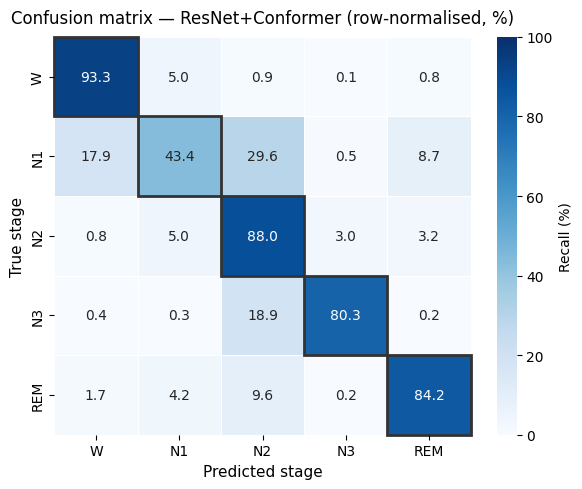

✓ Confusion matrix saved


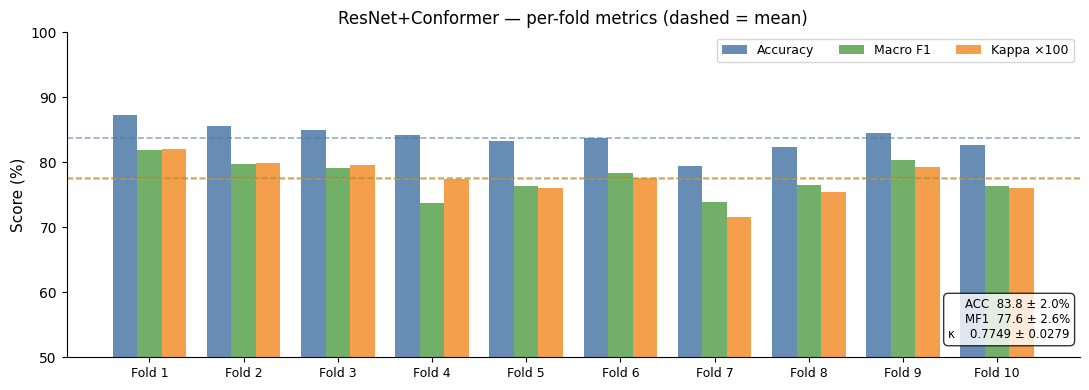

✓ Per-fold chart saved

Hypnogram: fold 1 (ACC=87.27%)


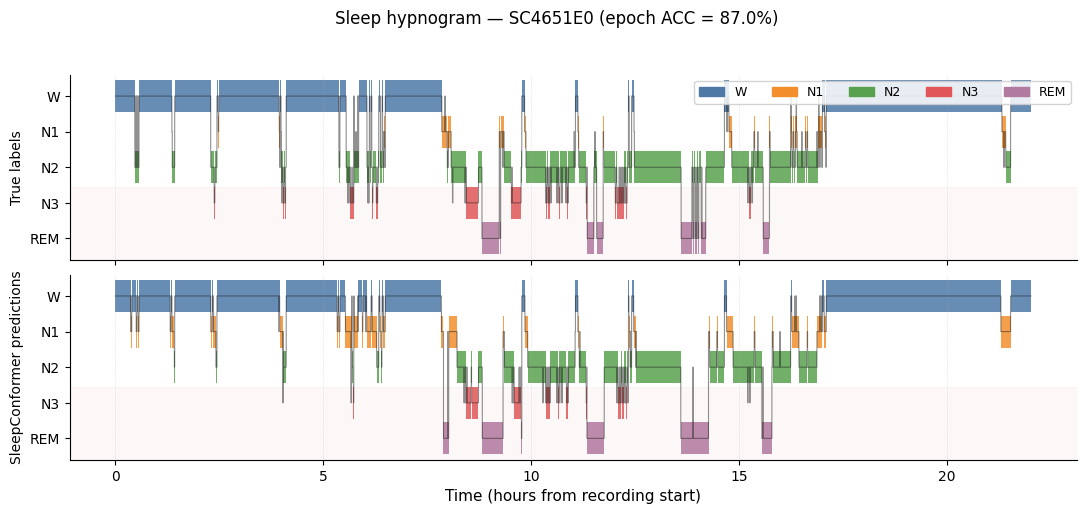

✓ Hypnogram saved  (record ACC=87.0%)


In [15]:
# ════════════════════════════════════════════════════════════════
# CELL 14 — Visualization
#   1. Confusion matrix (normalized)
#   2. Per-fold ACC / MF1 / Kappa  (bar chart)
#   3. Sleep hypnogram — 1 record: predicted vs true
# ════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

STAGE_COLORS = {
    'W'  : '#4e79a7',
    'N1' : '#f28e2b',
    'N2' : '#59a14f',
    'N3' : '#e15759',
    'REM': '#b07aa1',
}
STAGE_LIST = ['W', 'N1', 'N2', 'N3', 'REM']

def _despine(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── 1. CONFUSION MATRIX ──────────────────────────────────────────
fig1, ax = plt.subplots(figsize=(6, 5))
cm     = confusion_matrix(all_trues, all_preds, labels=list(range(N_CLASSES)))
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

sns.heatmap(
    cm_pct, annot=True, fmt='.1f', cmap='Blues',
    xticklabels=STAGE_LIST, yticklabels=STAGE_LIST,
    linewidths=0.4, linecolor='white', cbar_kws={'label': 'Recall (%)'},
    ax=ax, vmin=0, vmax=100,
)
ax.set_xlabel('Predicted stage', fontsize=11)
ax.set_ylabel('True stage', fontsize=11)
ax.set_title('Confusion matrix — ResNet+Conformer (row-normalised, %)', fontsize=12, pad=10)
ax.tick_params(axis='both', labelsize=10)

for i in range(N_CLASSES):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor='#333', lw=2, clip_on=False))

fig1.tight_layout()
fig1.savefig(OUT_DIR / 'cm_conformer.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Confusion matrix saved')

# ── 2. PER-FOLD ACC / MF1 / KAPPA ────────────────────────────────
folds  = [m['fold']        for m in fold_metrics]
accs   = [m['acc']  * 100  for m in fold_metrics]
mf1s   = [m['mf1']  * 100  for m in fold_metrics]
kappas = [m['kappa'] * 100 for m in fold_metrics]

x, width = np.arange(len(folds)), 0.26
fig2, ax = plt.subplots(figsize=(11, 4))

ax.bar(x - width, accs,   width, label='Accuracy',  color='#4e79a7', alpha=0.85)
ax.bar(x,          mf1s,  width, label='Macro F1',  color='#59a14f', alpha=0.85)
ax.bar(x + width, kappas, width, label='Kappa ×100',color='#f28e2b', alpha=0.85)

for vals, color in [(accs,'#4e79a7'),(mf1s,'#59a14f'),(kappas,'#f28e2b')]:
    ax.axhline(np.mean(vals), color=color, lw=1.2, ls='--', alpha=0.6)

ax.set_xticks(x)
ax.set_xticklabels([f'Fold {f}' for f in folds], fontsize=9)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('ResNet+Conformer — per-fold metrics (dashed = mean)', fontsize=12)
ax.set_ylim(50, 100)
ax.legend(fontsize=9, ncol=3)
_despine(ax)

stats_txt = f"ACC  {np.mean(accs):.1f} ± {np.std(accs):.1f}%\nMF1  {np.mean(mf1s):.1f} ± {np.std(mf1s):.1f}%\nκ    {np.mean(kappas)/100:.4f} ± {np.std(kappas)/100:.4f}"
ax.text(0.99, 0.05, stats_txt, transform=ax.transAxes, fontsize=8.5, va='bottom', ha='right', bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.8))

fig2.tight_layout()
fig2.savefig(OUT_DIR / 'per_fold_conformer.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Per-fold chart saved')

# ── 3. HYPNOGRAM ─────────────────────────────────────────────────
best_fold_idx = int(np.argmax([m['acc'] for m in fold_metrics]))
best_fold     = fold_metrics[best_fold_idx]
print(f'\nHypnogram: fold {best_fold["fold"]} (ACC={best_fold["acc"]*100:.2f}%)')

# Load ResNet
best_resnet = EEG_ResNet1D(feature_dim=N_FEAT, num_classes=N_CLASSES).to(DEVICE)
best_resnet.load_state_dict(torch.load(CKPT_DIR / f'resnet_fold{best_fold["fold"]}.pth', map_location=DEVICE, weights_only=True))
best_resnet.eval()

# Load Conformer
best_seq = SleepConformer(input_size=N_FEAT).to(DEVICE)
best_seq.load_state_dict(torch.load(SEQ_CKPT_DIR / f'conformer_scl_seqaug_fold{best_fold["fold"]}.pth', map_location=DEVICE, weights_only=True))
best_seq.eval()

# Tìm Record dài nhất trong Fold ngon nhất
test_sids_best = list(fold_groups[best_fold_idx])
test_recs_best = [r for s in test_sids_best for r in subject_records[s]]
rec = max(test_recs_best, key=lambda r: (r['lbls'] >= 0).sum())

# Trích xuất đặc trưng với ResNet
feat_rec = extract_features_resnet([rec], best_resnet)
feats, lbls = feat_rec[0]

with torch.no_grad():
    xb = torch.from_numpy(feats.astype(np.float32)).unsqueeze(0).to(DEVICE)
    prob = best_seq(xb).squeeze(0).cpu().numpy()
pred_all = prob.argmax(axis=1)

# Lọc valid epoch để vẽ
valid_mask = (lbls >= 0) & (lbls < N_CLASSES)
true_seq, pred_seq = lbls[valid_mask], pred_all[valid_mask]
T, time_hrs = len(true_seq), np.arange(len(true_seq)) * 30 / 3600
STAGE_Y = {'W': 4, 'N1': 3, 'N2': 2, 'N3': 1, 'REM': 0}

fig3, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True, gridspec_kw={'hspace': 0.08})
for ax_idx, (seq, title) in enumerate([(true_seq, 'True labels'), (pred_seq, 'SleepConformer predictions')]):
    ax = axes[ax_idx]
    for t in range(T):
        stage = STAGE_LIST[seq[t]]
        ax.fill_between([time_hrs[t], time_hrs[t] + 30/3600], [STAGE_Y[stage] - 0.45, STAGE_Y[stage] - 0.45], [STAGE_Y[stage] + 0.45, STAGE_Y[stage] + 0.45], color=STAGE_COLORS[stage], alpha=0.85, linewidth=0)
    step_y = [STAGE_Y[STAGE_LIST[s]] for s in seq]
    ax.step(time_hrs, step_y, where='post', color='#222', lw=0.8, alpha=0.5)
    ax.set_yticks(list(STAGE_Y.values()))
    ax.set_yticklabels(list(STAGE_Y.keys()), fontsize=10)
    ax.set_ylabel(title, fontsize=10)
    ax.set_ylim(-0.6, 4.6)
    ax.grid(axis='x', ls=':', lw=0.5, alpha=0.5)
    _despine(ax)
    ax.axhspan(-0.6, 1.45, color='#e15759', alpha=0.04)

axes[1].set_xlabel('Time (hours from recording start)', fontsize=11)
patches = [mpatches.Patch(color=STAGE_COLORS[s], label=s) for s in STAGE_LIST]
axes[0].legend(handles=patches, ncol=5, fontsize=9, loc='upper right', framealpha=0.85)
rec_acc = (true_seq == pred_seq).mean() * 100
fig3.suptitle(f'Sleep hypnogram — {rec["fname"]} (epoch ACC = {rec_acc:.1f}%)', fontsize=12, y=1.01)

fig3.tight_layout()
fig3.savefig(OUT_DIR / 'hypnogram_conformer.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Hypnogram saved  (record ACC={rec_acc:.1f}%)')